# Attention Core: Scores, Masks, Values, And KV Cache

We start with one attention head. Multi-head attention is just this same logic
run many times in parallel with different projections.

The core path is small:

1. Project hidden states into queries, keys, and values.
2. Compare each query with keys to get scores.
3. Mask future positions before softmax.
4. Softmax scores into attention weights.
5. Mix values using those weights.
6. During decode, cache keys and values so old tokens are not recomputed.


## Setup

In [2]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

torch.manual_seed(0)
torch.set_printoptions(precision=4, sci_mode=False)


def print_table(headers, rows):
    widths = [len(str(header)) for header in headers]
    for row in rows:
        for idx, value in enumerate(row):
            widths[idx] = max(widths[idx], len(str(value)))
    template = "  ".join(f"{{:<{width}}}" for width in widths)
    print(template.format(*headers))
    print(template.format(*["-" * width for width in widths]))
    for row in rows:
        print(template.format(*[str(value) for value in row]))

## Shape Notation

We use four symbols first:

- `B`: batch size
- `T`: number of token positions in the prompt
- `C`: model hidden size before attention projection
- `D`: single-head attention width after projection

For this notebook:

```text
x: [B, T, C]
q, k, v: [B, T, D]
scores: [B, T_query, T_key]
weights: [B, T_query, T_key]
out: [B, T_query, D]
```

There is no `H` yet. `H` appears in the next notebook when we run this same
logic across multiple heads.

In [3]:
# B: batch size. Keep it >1 so the code is really batched.
B = 2
# T: sequence length, meaning number of token positions in the prompt.
T = 8
# C: model hidden size before Q/K/V projection.
C = 12
# D: one attention head width after Q/K/V projection.
D = 6

shape_rows = [
    ["hidden states x", [B, T, C]],
    ["queries q", [B, T, D]],
    ["keys k", [B, T, D]],
    ["values v", [B, T, D]],
    ["attention scores", [B, T, T]],
    ["attention weights", [B, T, T]],
    ["attention output", [B, T, D]],
]
print_table(["tensor", "shape"], shape_rows)

tensor             shape     
-----------------  ----------
hidden states x    [2, 8, 12]
queries q          [2, 8, 6] 
keys k             [2, 8, 6] 
values v           [2, 8, 6] 
attention scores   [2, 8, 8] 
attention weights  [2, 8, 8] 
attention output   [2, 8, 6] 


## One Query, Three Keys

Before writing the vectorized version, look at one query manually.

A query does not directly copy a token. It scores keys, turns those scores into a
probability distribution, then uses that distribution to mix values.

In [4]:
query = torch.tensor([1.0, 0.0])
keys = torch.tensor(
    [
        [1.0, 0.0],  # strong match
        [0.0, 1.0],  # weak match
        [0.7, 0.7],  # partial match
    ]
)
values = torch.tensor(
    [
        [10.0, 0.0],
        [0.0, 10.0],
        [5.0, 5.0],
    ]
)

scores = query @ keys.T / math.sqrt(query.numel())
weights = torch.softmax(scores, dim=-1)
output = weights @ values

print_table(
    ["item", "value"],
    [
        ["raw scores", [round(x, 4) for x in scores.tolist()]],
        ["softmax weights", [round(x, 4) for x in weights.tolist()]],
        ["mixed output", [round(x, 4) for x in output.tolist()]],
    ],
)

item             value                   
---------------  ------------------------
raw scores       [0.7071, 0.0, 0.495]    
softmax weights  [0.4344, 0.2142, 0.3514]
mixed output     [6.1011, 3.8989]        


## Causal Mask

Decoder attention is causal: token `i` can read tokens `0..i`, but not future
tokens.

The mask is applied to scores before softmax. Future-token scores become `-inf`,
so softmax turns them into exact probability zero.

In [5]:
def causal_mask(q_len, k_len, device=None):
    q_pos = torch.arange(q_len, device=device)[:, None]
    k_pos = torch.arange(k_len, device=device)[None, :]
    return k_pos <= q_pos


mask = causal_mask(6, 6)
print(mask.int())

tensor([[1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1]], dtype=torch.int32)


## Vectorized Attention

Now write the real primitive.

The same function handles:

- full prefill: many queries read many keys
- decode: one query reads cached keys
- non-causal reads: when the caller has already restricted the cache

The important line is `scores = q @ k.transpose(-2, -1)`. It creates every
query-key comparison in one batched matmul.

In [6]:
def attention(q, k, v, *, causal=False):
    # q: [B, T_query, D]
    # k: [B, T_key, D]
    # v: [B, T_key, D]
    head_dim = q.shape[-1]
    scores = q @ k.transpose(-2, -1) / math.sqrt(head_dim)

    if causal:
        mask = causal_mask(q.shape[-2], k.shape[-2], q.device)
        scores = scores.masked_fill(~mask, float("-inf"))

    weights = torch.softmax(scores, dim=-1)
    out = weights @ v
    return out, weights, scores

## Q/K/V Projection

The model starts with hidden states `x`. Attention does not use `x` directly.
It learns three projections:

```text
q = x @ Wq
k = x @ Wk
v = x @ Wv
```

Queries decide what the current token is looking for. Keys describe what cached
tokens offer. Values carry the information that will be mixed into the output.

In [9]:
def project_qkv(x, wq, wk, wv):
    # x is [B, T, C]. Each projection maps from model width C to attention width D.
    q = x @ wq
    k = x @ wk
    v = x @ wv
    return q, k, v


def init_weight(in_dim, out_dim):
    return torch.randn(in_dim, out_dim) / math.sqrt(in_dim)


wq = init_weight(C, D)
wk = init_weight(C, D)
wv = init_weight(C, D)
wo = init_weight(D, C)
x = torch.randn(B, T, C)

q, k, v = project_qkv(x, wq, wk, wv)
print_table(
    ["tensor", "shape"],
    [
        ["x", list(x.shape)],
        ["q", list(q.shape)],
        ["k", list(k.shape)],
        ["v", list(v.shape)],
    ],
)

tensor  shape     
------  ----------
x       [2, 8, 12]
q       [2, 8, 6] 
k       [2, 8, 6] 
v       [2, 8, 6] 


## Prefill: Full Prompt In One Call

Prefill runs when the prompt is already known. All tokens are projected together,
and causal masking prevents future reads.

This is where the initial KV cache is created.

In [10]:
def prefill(x, wq, wk, wv, wo):
    q, k, v = project_qkv(x, wq, wk, wv)
    attn_out, weights, scores = attention(q, k, v, causal=True)
    y = attn_out @ wo
    return y, k, v, weights, scores


prefill_y, prefill_k, prefill_v, prefill_weights, prefill_scores = prefill(x, wq, wk, wv, wo)

print_table(
    ["result", "shape"],
    [
        ["prefill_y", list(prefill_y.shape)],
        ["prefill_k cache", list(prefill_k.shape)],
        ["prefill_v cache", list(prefill_v.shape)],
        ["attention weights", list(prefill_weights.shape)],
    ],
)

result             shape     
-----------------  ----------
prefill_y          [2, 8, 12]
prefill_k cache    [2, 8, 6] 
prefill_v cache    [2, 8, 6] 
attention weights  [2, 8, 8] 


## What The Weights Look Like

For one batch item, the attention weight matrix is lower triangular because of
the causal mask. Each row is one query position. Each column is one key position.
Rows sum to 1 over the visible prefix.

row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


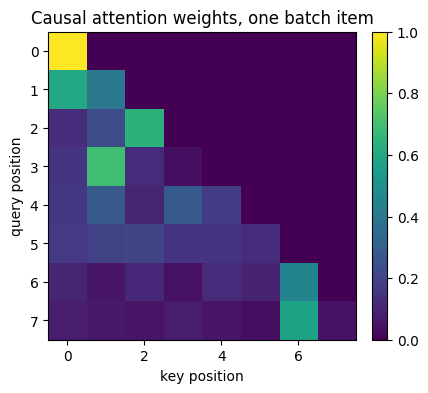

In [11]:
weights0 = prefill_weights[0].detach()
row_sums = weights0.sum(dim=-1)
print("row sums:", row_sums)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights0, cmap="viridis")
ax.set_title("Causal attention weights, one batch item")
ax.set_xlabel("key position")
ax.set_ylabel("query position")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Decode: One Token Query, Growing KV Cache

During generation, the model receives one new token at a time.

For each new token:

1. Project only that token into `q_t`, `k_t`, and `v_t`.
2. Append `k_t` and `v_t` to the cache.
3. Let `q_t` attend over the cache.
4. Return one output token.

There is no future mask inside the decode attention call because the cache only
contains tokens that are allowed to be read.

In [12]:
def append_cache(cache, new_value):
    # Cache shape grows along tokens: [B, cache_len, D].
    if cache is None:
        return new_value
    return torch.cat([cache, new_value], dim=1)


def decode_step(x_t, wq, wk, wv, wo, cache_k=None, cache_v=None):
    # x_t is a single token: [B, 1, C].
    q_t, k_t, v_t = project_qkv(x_t, wq, wk, wv)
    cache_k = append_cache(cache_k, k_t)
    cache_v = append_cache(cache_v, v_t)

    attn_out, weights, scores = attention(q_t, cache_k, cache_v, causal=False)
    y_t = attn_out @ wo
    return y_t, cache_k, cache_v, weights, scores


cache_k = None
cache_v = None
decode_outputs = []
decode_read_rows = []

for t in range(T):
    x_t = x[:, t : t + 1, :]
    y_t, cache_k, cache_v, weights_t, scores_t = decode_step(
        x_t,
        wq,
        wk,
        wv,
        wo,
        cache_k,
        cache_v,
    )
    decode_outputs.append(y_t)
    cache_len = cache_k.shape[1]
    decode_read_rows.append([t, cache_len, 2 * cache_len * D, 2 * D])

decode_y = torch.cat(decode_outputs, dim=1)
print_table(
    ["result", "shape"],
    [
        ["decode_y", list(decode_y.shape)],
        ["final cache_k", list(cache_k.shape)],
        ["final cache_v", list(cache_v.shape)],
    ],
)

result         shape     
-------------  ----------
decode_y       [2, 8, 12]
final cache_k  [2, 8, 6] 
final cache_v  [2, 8, 6] 


## Decode Read/Write Growth

Even with one attention head, the cache behavior is the key inference idea.
Each step writes one new key and one new value. But the next query reads the
whole visible cache.

For single-head attention:

```text
write scalars per token = 2 * D
read scalars at cache length L = 2 * L * D
```

MHA multiplies this by the number of KV heads. MQA, GQA, MLA, and sparse
attention change this path in different ways.

step  cache_len  read_scalars  write_scalars
----  ---------  ------------  -------------
0     1          12            12           
1     2          24            12           
2     3          36            12           
3     4          48            12           
4     5          60            12           
5     6          72            12           
6     7          84            12           
7     8          96            12           


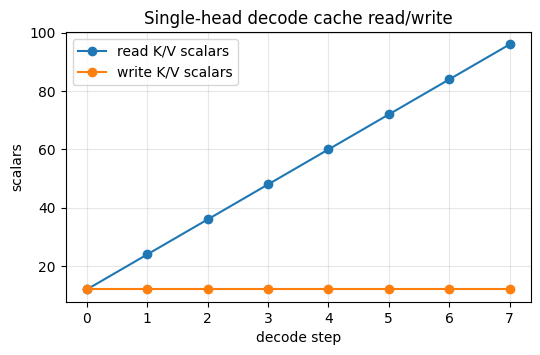

In [13]:
print_table(
    ["step", "cache_len", "read_scalars", "write_scalars"],
    decode_read_rows,
)

steps = [row[0] for row in decode_read_rows]
read_scalars = [row[2] for row in decode_read_rows]
write_scalars = [row[3] for row in decode_read_rows]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(steps, read_scalars, marker="o", label="read K/V scalars")
ax.plot(steps, write_scalars, marker="o", label="write K/V scalars")
ax.set_xlabel("decode step")
ax.set_ylabel("scalars")
ax.set_title("Single-head decode cache read/write")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Prefill And Decode Should Match

If the weights are the same and there is no dropout, full causal prefill and
step-by-step decode should produce the same output.

This check is one of the best ways to catch causal-mask or cache-layout bugs.

In [14]:
max_abs_error = (prefill_y - decode_y).abs().max().item()
print(f"max_abs_error = {max_abs_error:.8f}")
print("allclose", torch.allclose(prefill_y, decode_y, atol=1e-5, rtol=1e-5))

max_abs_error = 0.00000000
allclose True


## Cross-Check With PyTorch SDPA

PyTorch's optimized `scaled_dot_product_attention` expects a head dimension, so
we temporarily add one fake head:

```text
[B, T, D] -> [B, 1, T, D]
```

This confirms our manual attention primitive matches the standard API for the
same small case.

In [15]:
q, k, v = project_qkv(x, wq, wk, wv)
manual_out, _, _ = attention(q, k, v, causal=True)

torch_out = F.scaled_dot_product_attention(
    q.unsqueeze(1),
    k.unsqueeze(1),
    v.unsqueeze(1),
    is_causal=True,
).squeeze(1)

print("manual vs torch SDPA", torch.allclose(manual_out, torch_out, atol=1e-5, rtol=1e-5))
print("max_abs_error", (manual_out - torch_out).abs().max().item())

manual vs torch SDPA True
max_abs_error 2.384185791015625e-07


## What To Carry Forward

Core attention has two separate ideas:

- **Attention math:** scores, mask, softmax, value mixing.
- **Inference state:** cached keys and values grow during decode.

The next notebook adds multiple heads. It should not change the core math. It
changes the layout from:

```text
single-head: q, k, v = [B, T, D]
multi-head:  q, k, v = [B, H, T, D]
```

Once that layout is clear, MQA, GQA, MLA, and sparse attention become easier to
reason about because each one changes what is stored or read from the cache.